# World Cup Climate — demo

For a given match day, compare the **match-day climate** three ways:

1. **Venue, now** — the stadium's current 30-day window.
2. **Capitals, now** — the two competing nations' capital cities, current window.
3. **Capitals, climatology** — the same calendar window averaged over the last 10 years.

**Variables (sports-relevant):** 2 m temperature (`t2m`), 2 m dewpoint (`d2m`) → relative humidity, total precipitation (`tp`), surface solar radiation (`ssrd`).

**Data**

| role | Arraylake repo | group | grid | notes |
|---|---|---|---|---|
| reanalysis (history) | `earthmover-public/era5-private` | `single/temporal` | 0.25° | hourly since 1940; ~6-day latency; chunked for point time series |
| forecast (recent + ahead) | `spring-data/ecmwf-ifs-15-day-forecast-low-latency-subscription` | root | 0.1° | `(init, step)`; bridges the ERA5 latency gap |

**Access:** ERA5 point series go through the Flux **EDR** service (`edr-bf7f8f8c`, OGC Environmental Data Retrieval) — the right Flux service for *“values at a lat/lon over time”* in a web app. The forecast repo has no Flux service deployed, so it uses the Arraylake Python client. Set `ARRAYLAKE_TOKEN` for live data.

> This notebook runs offline with **synthetic data** (`WCC_DATA_SOURCE=fake`) so it works without a token — the fake provider mimics the *raw hourly* returns from Arraylake, including a realistic diurnal cycle. Set `WCC_DATA_SOURCE=live` (and `ARRAYLAKE_TOKEN`) to hit the real datasets.

In [1]:
import os, datetime as dt
os.environ.setdefault("WCC_DATA_SOURCE", "fake")  # set to 'live' + ARRAYLAKE_TOKEN for real data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from world_cup_climate import climate, fixtures, providers, config

MATCHDAY = dt.date(2026, 6, 15)
print("data source:", providers.data_source())
print("ERA5 cutoff:", providers.era5_cutoff(MATCHDAY), "(forecast fills the gap to the match day)")

data source: fake
ERA5 cutoff: 2026-06-09 (forecast fills the gap to the match day)


## 1. Raw hourly returns — the diurnal cycle

Everything is built from *raw hourly* point series. Below: a few days at one capital, showing the daily temperature and solar-radiation cycle that we later aggregate to UTC daily values.

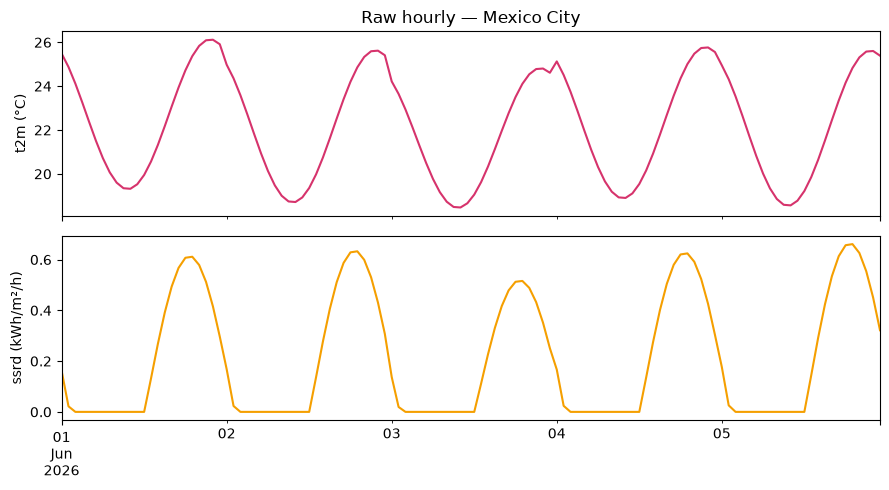

In [2]:
cap = fixtures.capital("Mexico")
hourly = providers.hourly_point("era5", cap["lat"], cap["lon"], "2026-06-01", "2026-06-05")

fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
(hourly["t2m"] - 273.15).plot(ax=ax[0], color="#d6336c")
ax[0].set_ylabel("t2m (°C)"); ax[0].set_title(f"Raw hourly — {cap['name']}")
(hourly["ssrd"] / 3.6e6).plot(ax=ax[1], color="#f59f00")
ax[1].set_ylabel("ssrd (kWh/m²/h)"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

## 2. Daily aggregation (UTC day)

ERA5 is UTC; to avoid sensitivity to a particular local hour, every variable is aggregated over the whole UTC calendar day — **mean** for instantaneous fields (`t2m`, `d2m`), **total** for accumulations (`tp`, `ssrd`).

In [3]:
daily_native = providers.daily_point("era5", cap["lat"], cap["lon"], "2026-06-01", "2026-06-10")
climate.to_display_units(daily_native).round(2)

,t2m,d2m,tp,ssrd,rh
2026-06-01,22.72,17.93,0.00,5.06,74.40
2026-06-02,22.17,17.17,0.00,5.24,73.36
2026-06-03,21.64,17.75,11.78,4.27,78.57
2026-06-04,22.33,17.42,0.00,5.17,73.74
2026-06-05,22.08,16.82,0.00,5.48,72.10
2026-06-06,24.18,18.16,5.78,6.14,69.13
2026-06-07,24.57,18.65,1.61,6.06,69.61
2026-06-08,21.61,15.78,8.61,5.98,69.43
2026-06-09,23.72,17.03,3.91,6.73,66.20
2026-06-10,19.46,13.04,7.64,6.50,66.43


## 3. Current window: ERA5 spliced with the forecast

The 30-day window ending on the match day is reanalysis up to the ERA5 cutoff, then forecast. The `source` column marks which is which.

In [4]:
cur = climate.current_series(cap["lat"], cap["lon"], MATCHDAY)
print(cur["source"].value_counts().to_dict())
cur.tail(8).round(2)

{'era5': 24, 'forecast': 6}


,t2m,d2m,tp,ssrd,rh,source
2026-06-08,21.61,15.78,8.61,5.98,69.43,era5
2026-06-09,23.72,17.03,3.91,6.73,66.20,era5
2026-06-10,19.46,13.04,7.64,6.50,66.43,forecast
2026-06-11,21.91,14.49,0.00,7.37,62.79,forecast
2026-06-12,23.99,17.50,0.00,6.56,67.06,forecast
2026-06-13,25.48,19.81,15.19,5.84,70.90,forecast
2026-06-14,28.63,19.63,9.30,8.76,58.28,forecast
2026-06-15,22.12,15.30,4.14,6.86,65.28,forecast


## 4. 10-year climatology at a capital

For each of the previous 10 years, the same calendar window is pulled from ERA5 and aggregated by day-offset (`0` = match day) into a mean and a p10–p90 band.

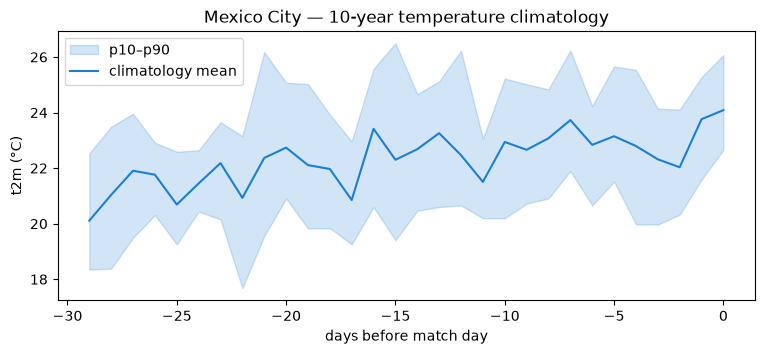

In [5]:
clim = climate.climatology(cap["lat"], cap["lon"], MATCHDAY)
off = clim.index
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.fill_between(off, clim["t2m_p10"], clim["t2m_p90"], alpha=0.2, color="#1c7ed6", label="p10–p90")
ax.plot(off, clim["t2m_mean"], color="#1c7ed6", label="climatology mean")
ax.set_xlabel("days before match day"); ax.set_ylabel("t2m (°C)")
ax.set_title(f"{cap['name']} — 10-year temperature climatology"); ax.legend(); plt.show()

## 5. Three-way comparison for a match

`build_match_report` assembles venue + both capitals (current + climatology) — this is exactly what the FastAPI app serves to the frontend.

Mexico vs Croatia @ Estadio Azteca


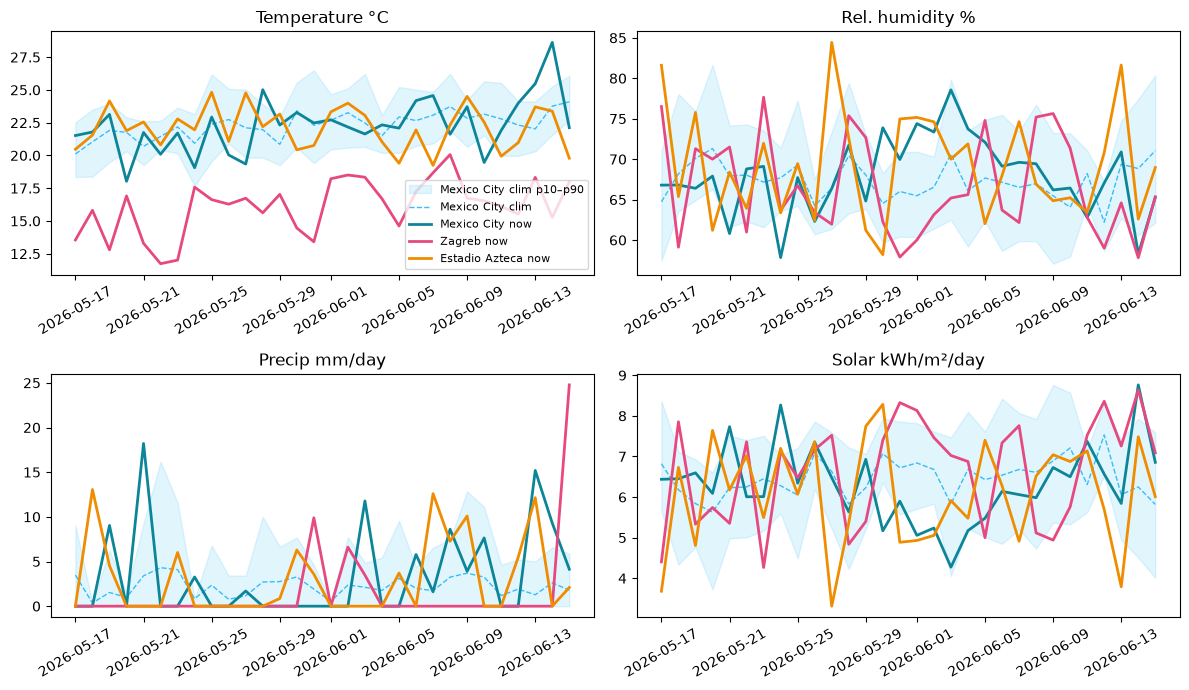

In [6]:
match = fixtures.matches_on(MATCHDAY)[0]
rep = climate.build_match_report(match)
print(match["home"], "vs", match["away"], "@", rep["venue"]["name"])

home, away, venue = rep["capitals"]["home"], rep["capitals"]["away"], rep["venue"]
dates = pd.to_datetime(home["current"]["dates"])

def series(block, var):
    return pd.Series(block["current"]["values"][var], index=pd.to_datetime(block["current"]["dates"]))

panel = [("t2m", "Temperature °C"), ("rh", "Rel. humidity %"), ("tp", "Precip mm/day"), ("ssrd", "Solar kWh/m²/day")]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for (var, title), ax in zip(panel, axes.ravel()):
    hc = home["climatology"]["values"].get(var, {})
    if hc:
        ax.fill_between(dates, hc["p10"], hc["p90"], color="#38bdf8", alpha=0.15, label=f"{home['name']} clim p10–p90")
        ax.plot(dates, hc["mean"], color="#38bdf8", ls="--", lw=1, label=f"{home['name']} clim")
    ax.plot(dates, series(home, var), color="#0c8599", lw=2, label=f"{home['name']} now")
    ax.plot(dates, series(away, var), color="#e64980", lw=2, label=f"{away['name']} now")
    ax.plot(dates, series(venue, var), color="#f08c00", lw=2, label=f"{venue['name']} now")
    ax.set_title(title); ax.tick_params(axis="x", rotation=30)
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Match-day summary (anomaly vs. climatology)

In [7]:
rows = []
for side, block in (("home", home), ("away", away)):
    for var, s in block["summary"].items():
        rows.append({"capital": block["name"], "variable": var, **s})
pd.DataFrame(rows).set_index(["capital", "variable"]).round(2)

now  clim_mean  clim_p10  clim_p90  anomaly
capital     variable                                               
Mexico City t2m       22.12      24.09     22.66     26.07    -1.97
            d2m       15.30      18.45     15.59     21.43    -3.15
            rh        65.28      71.05     62.13     80.35    -5.77
            tp         4.14       1.79      0.00      5.89     2.35
            ssrd       6.86       5.82      4.01      7.59     1.04
Zagreb      t2m       17.98      17.31     15.95     19.14     0.67
            d2m       11.38      11.62      9.11     14.16    -0.24
            rh        65.35      69.56     60.52     78.51    -4.21
            tp        24.77       1.63      0.00      3.80    23.13
            ssrd       7.09       6.24      4.42      8.14     0.85

## Run the web app

```bash
# offline / demo (synthetic data, no token):
WCC_DATA_SOURCE=fake uv run world-cup-climate

# live data:
export ARRAYLAKE_TOKEN=ema_...
WCC_DATA_SOURCE=live uv run world-cup-climate
```
Then open http://127.0.0.1:8000 . The same `build_match_report` shown here powers `GET /api/report/{idx}`.